<a href="https://colab.research.google.com/github/mahmadulhasan/Aave-coin-clone-react-tailwind/blob/main/ML_insurence_data_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# checking null values
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
data.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

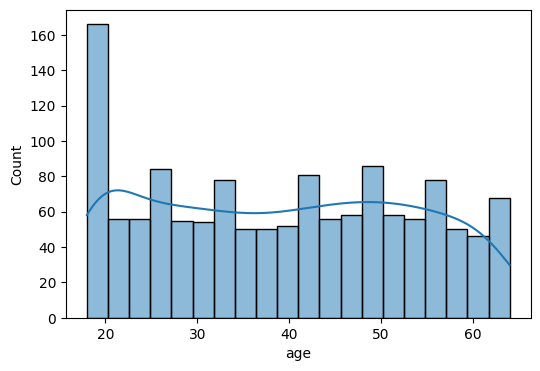

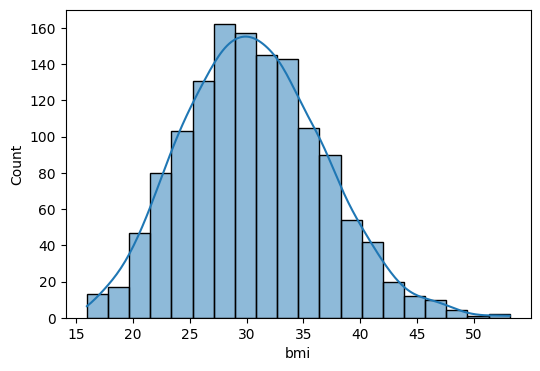

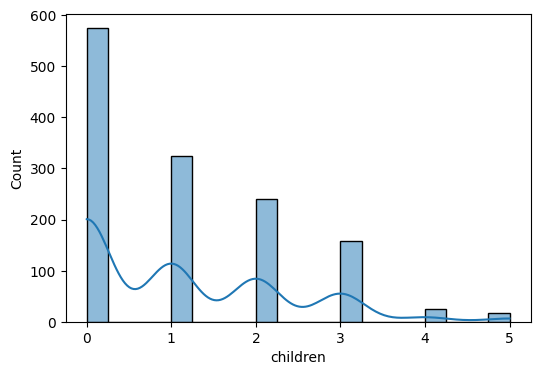

In [ ]:
numeric_column = ['age',  'bmi', 'children']
for col in numeric_column:
  plt.figure(figsize=(6,4))
  sns.histplot(data[col],kde=True , bins=20)

<Axes: >

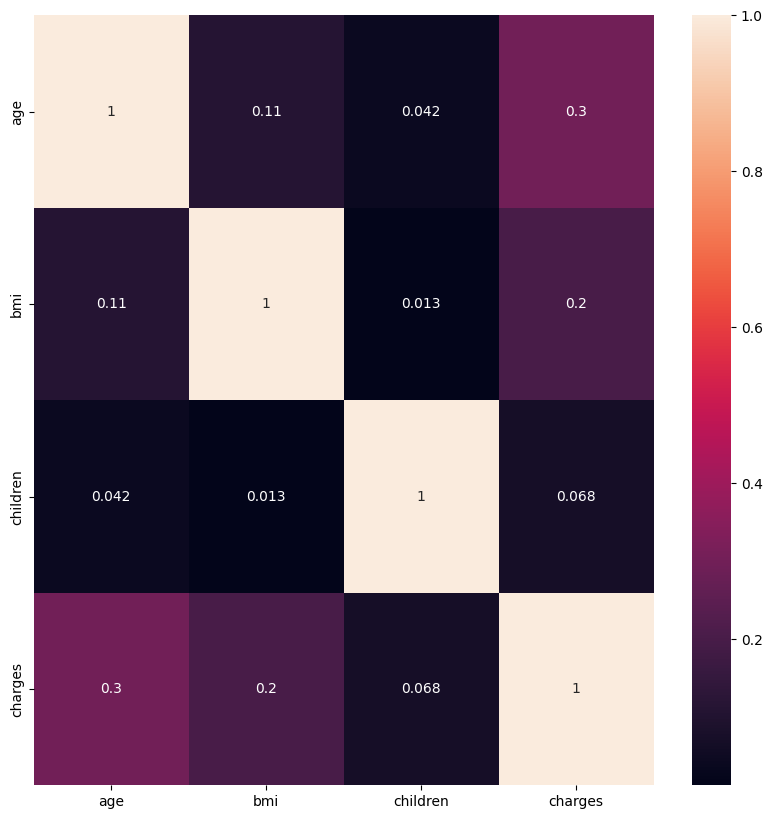

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(numeric_only=True),annot=True)

Data cleaning and Processing

In [ ]:
data_clean = data.copy()
data_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data_clean.drop_duplicates(inplace=True)

In [ ]:
# converting the string into numeric
data_clean['sex'] = data_clean['sex'].map({'male':0, 'female':1})
data_clean['smoker'] = data_clean['smoker'].map({'yes':1, 'no':0})
data_clean.head()


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [ ]:
data_clean.rename(columns= {
    'sex':'isFemale',
    'smoker':'isSmoker',

},inplace= True)
data_clean.head()

,age,isFemale,bmi,children,isSmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [ ]:
data_clean = pd.get_dummies(data_clean, columns= ['region'], drop_first=True)


In [ ]:
data_clean

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

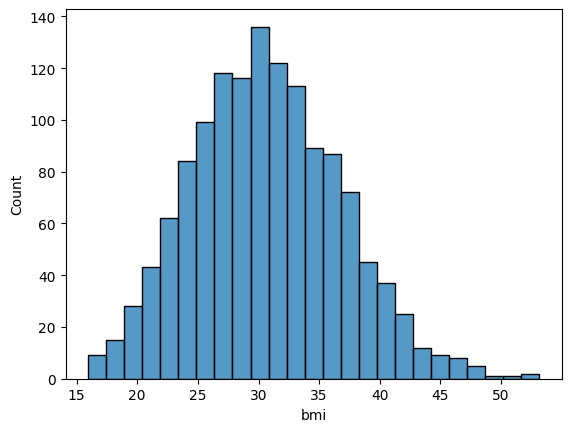

In [ ]:
sns.histplot(data['bmi'])

In [ ]:
data_clean['bmi_catergory'] = pd.cut(
    data_clean['bmi'],
    bins=[0,18.5,24.9,29.9, float('inf')],
    labels=['Underweight','Normal','Overweight','Obese']

    )
data_clean.head(

)

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_catergory
0,19,1,27.900,0,1,16884.92400,False,False,True,Overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,Obese
2,28,0,33.000,3,0,4449.46200,False,True,False,Obese
3,33,0,22.705,0,0,21984.47061,True,False,False,Normal
4,32,0,28.880,0,0,3866.85520,True,False,False,Overweight


In [ ]:
data_clean = pd.get_dummies(data_clean, columns=['bmi_catergory'], drop_first= True)

In [ ]:
data_clean = data_clean.astype(int)

In [ ]:
data_clean

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_catergory_Normal,bmi_catergory_Overweight,bmi_catergory_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [ ]:
from sklearn.preprocessing import  StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

data_clean[cols] = scaler.fit_transform(data_clean[cols])
# Now evry data converted in 0 1-

In [ ]:
data_clean

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_catergory_Normal,bmi_catergory_Overweight,bmi_catergory_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


In [ ]:
data_clean.columns

Index(['age', 'isFemale', 'bmi', 'children', 'isSmoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_catergory_Normal', 'bmi_catergory_Overweight',
       'bmi_catergory_Obese'],
      dtype='object')

In [ ]:
from scipy.stats import pearsonr

selected_feature =  ['age', 'isFemale', 'bmi', 'children', 'isSmoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_catergory_Normal', 'bmi_catergory_Overweight',
       'bmi_catergory_Obese']

correlation = {
    feature: pearsonr(data_clean[feature],data_clean['charges'])[0]
    for feature in selected_feature
}

correlation_df = pd.DataFrame(list(correlation.items()),columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,isSmoker,0.787234
0,age,0.298309
10,bmi_catergory_Obese,0.197660
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,isFemale,-0.058046
8,bmi_catergory_Normal,-0.105656


In [ ]:
cat_features = [
    'isFemale', 'isSmoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_catergory_Normal', 'bmi_catergory_Overweight', 'bmi_catergory_Obese'
]

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

data_clean['charges_bin'] = pd.qcut(data_clean['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(data_clean[col], data_clean['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
isSmoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
isFemale,10.258784,0.01649,Reject Null (Keep Feature)
bmi_catergory_Obese,7.654464,0.05372,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_catergory_Normal,4.263673,0.234364,Accept Null (Drop Feature)
bmi_catergory_Overweight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [ ]:
final_df = data_clean[['age', 'isFemale', 'bmi', 'children', 'isSmoker', 'charges','region_southeast','bmi_catergory_Obese']]

In [ ]:
final_df

,age,isFemale,bmi,children,isSmoker,charges,region_southeast,bmi_catergory_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0
